In [ ]:
BEST_THRESHOLDS = {}

In [2]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset
from transformers import BertTokenizer, BertForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_recall_fscore_support
from tqdm.auto import tqdm

# Bật TensorBoard
%load_ext tensorboard

# Khởi tạo Tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
LABEL_COLS = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# 1. Đọc dữ liệu
train_df = pd.read_csv('/content/train_clean.csv')
test_df = pd.read_csv('/content/test_clean.csv')
test_labels = pd.read_csv('/content/test_labels.csv')

# 2. Xử lý tập test
# Gộp test.csv và test_labels.csv dựa trên 'id'
test_merged = test_df.merge(test_labels, on='id')

# Nhãn -1 nghĩa là mẫu đó không được dùng để chấm điểm. Phải loại bỏ.
print(f"Số lượng tập test trước khi lọc: {len(test_merged)}")
test_filtered = test_merged[test_merged['toxic'] != -1].reset_index(drop=True)
print(f"Số lượng tập test sau khi lọc (bỏ -1): {len(test_filtered)}")


Số lượng tập test trước khi lọc: 153164
Số lượng tập test sau khi lọc (bỏ -1): 63978


Tokenizing samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (806 > 512). Running this sequence through the model will result in indexing errors



--- THỐNG KÊ ĐỘ DÀI TOKENS ---
Độ dài trung bình: 44
Độ dài trung vị (Median): 25
Bách phân vị 90%: 94
Bách phân vị 95%: 140
Bách phân vị 99%: 358
Độ dài tối đa (Max): 1114


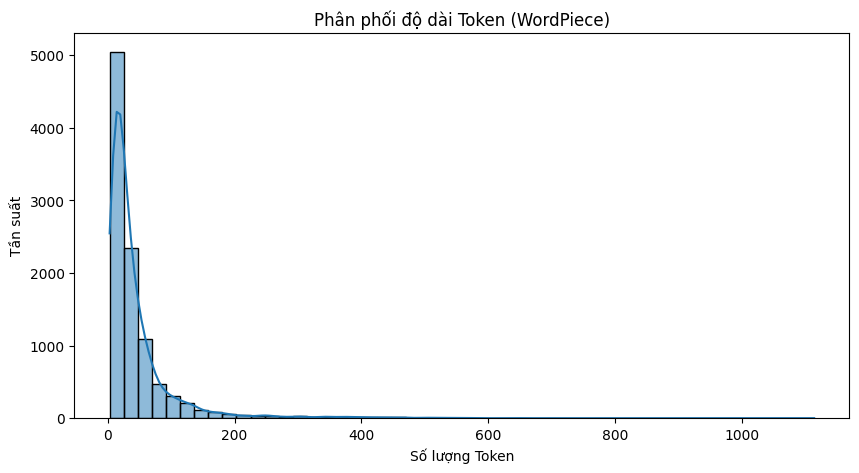

In [8]:
def analyze_token_lengths(texts, tokenizer, sample_size=10000):
    """
    Hàm lấy mẫu và phân tích độ dài token để tìm MAX_LENGTH phù hợp.
    """
    sample_texts = texts.sample(min(sample_size, len(texts))).tolist()

    lengths = []
    for text in tqdm(sample_texts, desc="Tokenizing samples"):
        tokens = tokenizer.encode(str(text), add_special_tokens=True)
        lengths.append(len(tokens))

    lengths = np.array(lengths)

    print("\n--- THỐNG KÊ ĐỘ DÀI TOKENS ---")
    print(f"Độ dài trung bình: {lengths.mean():.0f}")
    print(f"Độ dài trung vị (Median): {np.median(lengths):.0f}")
    print(f"Bách phân vị 90%: {np.percentile(lengths, 90):.0f}")
    print(f"Bách phân vị 95%: {np.percentile(lengths, 95):.0f}")
    print(f"Bách phân vị 99%: {np.percentile(lengths, 99):.0f}")
    print(f"Độ dài tối đa (Max): {lengths.max():.0f}")

    # Vẽ biểu đồ
    plt.figure(figsize=(10, 5))
    sns.histplot(lengths, bins=50, kde=True)
    plt.title("Phân phối độ dài Token (WordPiece)")
    plt.xlabel("Số lượng Token")
    plt.ylabel("Tần suất")
    plt.show()

    return lengths

# Chạy phân tích trên tập train
_ = analyze_token_lengths(train_df['comment_text'], tokenizer)
MAX_LENGTH = 128

In [9]:
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts.values
        self.labels = labels.values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])


        inputs = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_token_type_ids=False
        )

        return {
            'input_ids': torch.tensor(inputs['input_ids'], dtype=torch.long),
            'attention_mask': torch.tensor(inputs['attention_mask'], dtype=torch.long),
            'labels': torch.tensor(self.labels[item], dtype=torch.float)
        }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.sigmoid(torch.from_numpy(logits)).numpy()

    auc_scores = []
    # Tính ROC AUC cho từng class
    for i in range(labels.shape[1]):
        try:
            auc = roc_auc_score(labels[:, i], probs[:, i])
            auc_scores.append(auc)
        except ValueError:
            auc_scores.append(0.5)

    mean_auc = np.mean(auc_scores)

    if 'BEST_THRESHOLDS' in globals() and BEST_THRESHOLDS:
      thresh_arr = np.array([BEST_THRESHOLDS.get(col, 0.5) for col in LABEL_COLS])
      preds = (probs >= thresh_arr).astype(int)
    else:
      preds = (probs > 0.5).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro', zero_division=0)
    acc = accuracy_score(labels, preds)

    return {
        'roc_auc': mean_auc,
        'f1_macro': f1,
        'precision': precision,
        'recall': recall,
        'accuracy': acc
    }


from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

train_dataset = ToxicDataset(train_data['comment_text'], train_data[LABEL_COLS], tokenizer, MAX_LENGTH)
val_dataset = ToxicDataset(val_data['comment_text'], val_data[LABEL_COLS], tokenizer, MAX_LENGTH)

# Dataset cho tập test (dùng test_filtered đã bỏ nhãn -1)
test_dataset = ToxicDataset(test_filtered['comment_text'], test_filtered[LABEL_COLS], tokenizer, MAX_LENGTH)

In [11]:

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLS),
    problem_type="multi_label_classification"
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=4,              # Tăng lên 3-4 nếu có thời gian
    per_device_train_batch_size=32,  # Giảm xuống 16 nếu bị Out Of Memory (OOM)
    per_device_eval_batch_size=64,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='/content/logs', # Sửa thành đường dẫn tuyệt đối
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="roc_auc",
    fp16=True,
    report_to="tensorboard"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# Bắt đầu quá trình huấn luyện
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Step,Training Loss,Validation Loss,Roc Auc,F1 Macro,Precision,Recall,Accuracy
500,0.058387,0.054525,0.941942,0.355500,0.329198,0.386727,0.917248
1000,0.045003,0.045454,0.973189,0.349072,0.405866,0.306303,0.929994
1500,0.047243,0.044328,0.975770,0.370208,0.369910,0.376031,0.929727
2000,0.045201,0.041713,0.971928,0.378516,0.372109,0.386955,0.931262
2500,0.039944,0.039857,0.973028,0.371641,0.399130,0.348448,0.931696
3000,0.042377,0.039059,0.981274,0.470875,0.579007,0.444152,0.927859
3500,0.039281,0.045563,0.978391,0.356497,0.746732,0.289225,0.929160
4000,0.034343,0.038712,0.980559,0.435713,0.746744,0.388284,0.932897
4500,0.034272,0.040065,0.980421,0.529519,0.618113,0.510002,0.931362
5000,0.031551,0.041281,0.978492,0.555598,0.631302,0.500370,0.933398


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=14988, training_loss=0.033303459413789066, metrics={'train_runtime': 5284.3363, 'train_samples_per_second': 90.739, 'train_steps_per_second': 2.836, 'total_flos': 3.154130739623117e+16, 'train_loss': 0.033303459413789066, 'epoch': 4.0})

In [12]:
print("\n--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST ---")

# Dùng trainer.predict để lấy logits trên tập test_dataset
test_results = trainer.predict(test_dataset)

# In ra các metrics (ROC_AUC, F1, Accuracy) trên tập Test
print("\nKết quả Metrics trên tập Test:")
for key, value in test_results.metrics.items():
    print(f"{key}: {value:.4f}")

# Xuất file kết quả dự đoán (Probabilities)
probs = torch.sigmoid(torch.from_numpy(test_results.predictions)).numpy()

submission_df = pd.DataFrame(probs, columns=LABEL_COLS)
submission_df.insert(0, 'id', test_filtered['id'].values)

submission_df.to_csv('final_predictions.csv', index=False)
print("\nĐã lưu file dự đoán: final_predictions.csv")


--- BẮT ĐẦU ĐÁNH GIÁ TRÊN TẬP TEST ---



Kết quả Metrics trên tập Test:
test_loss: 0.0617
test_roc_auc: 0.9802
test_f1_macro: 0.4159
test_precision: 0.6564
test_recall: 0.3787
test_accuracy: 0.8808
test_runtime: 116.3698
test_samples_per_second: 549.7820
test_steps_per_second: 8.5930

Đã lưu file dự đoán: final_predictions.csv


In [13]:
# ==========================================
# TỐI ƯU THRESHOLD CHO TỪNG LABEL (PER-LAYER THRESHOLD OPTIMIZATION)
# ==========================================

from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold_per_label(y_true, y_probs, label_cols, thresholds=None):
    """
    Tìm ngưỡng (threshold) tối ưu cho từng label riêng biệt
    dựa trên tập validation bằng cách tối đa hóa F1-score.

    Args:
        y_true  : numpy array shape (N, num_labels) - nhãn thật
        y_probs : numpy array shape (N, num_labels) - xác suất dự đoán (sau sigmoid)
        label_cols : list[str] - tên các label
        thresholds : list[float] - các giá trị threshold cần thử (mặc định 0.1 -> 0.9)

    Returns:
        best_thresholds : dict {label_name: best_threshold}
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.01)  # 0.10, 0.11, ..., 0.90

    best_thresholds = {}

    print("\n--- TỐI ƯU THRESHOLD CHO TỪNG LABEL ---")
    print(f"{'Label':<20} {'Best Threshold':>16} {'Best F1':>10}")
    print("-" * 50)

    for i, label in enumerate(label_cols):
        best_f1 = -1
        best_thresh = 0.5  # fallback

        for thresh in thresholds:
            preds = (y_probs[:, i] >= thresh).astype(int)
            f1 = f1_score(y_true[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_thresh = thresh

        best_thresholds[label] = round(float(best_thresh), 2)
        print(f"{label:<20} {best_thresh:>16.2f} {best_f1:>10.4f}")

    print("-" * 50)
    print(f"\nThreshold mặc định (0.5) cho tất cả label đã được thay thế bằng:")
    print(best_thresholds)
    return best_thresholds


def evaluate_with_best_thresholds(y_true, y_probs, best_thresholds, label_cols):
    """
    Đánh giá lại toàn bộ tập với threshold tối ưu từng label.
    In ra bảng so sánh trước/sau tối ưu.
    """
    from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

    # Dự đoán với threshold tối ưu
    preds_opt = np.zeros_like(y_probs, dtype=int)
    for i, label in enumerate(label_cols):
        preds_opt[:, i] = (y_probs[:, i] >= best_thresholds[label]).astype(int)

    # Dự đoán với threshold mặc định 0.5
    preds_default = (y_probs >= 0.5).astype(int)

    print("\n--- SO SÁNH TRƯỚC / SAU TỐI ƯU THRESHOLD ---")
    print(f"{'Label':<20} {'F1 (0.5)':>10} {'F1 (opt)':>10} {'Threshold':>10}")
    print("-" * 55)

    for i, label in enumerate(label_cols):
        f1_default = f1_score(y_true[:, i], preds_default[:, i], zero_division=0)
        f1_opt     = f1_score(y_true[:, i], preds_opt[:, i],     zero_division=0)
        print(f"{label:<20} {f1_default:>10.4f} {f1_opt:>10.4f} {best_thresholds[label]:>10.2f}")

    print("-" * 55)

    # Macro F1 tổng
    f1_default_macro = f1_score(y_true, preds_default, average='macro', zero_division=0)
    f1_opt_macro     = f1_score(y_true, preds_opt,     average='macro', zero_division=0)
    print(f"{'[Macro F1 tổng]':<20} {f1_default_macro:>10.4f} {f1_opt_macro:>10.4f}")

    return preds_opt


# ==========================================
# BƯỚC 1: Lấy xác suất dự đoán trên tập VALIDATION
# ==========================================
print("[BƯỚC 1] Predict trên tập validation để tối ưu threshold...")
val_results = trainer.predict(val_dataset)
val_probs   = torch.sigmoid(torch.from_numpy(val_results.predictions)).numpy()
val_labels  = val_results.label_ids.astype(int)

# ==========================================
# BƯỚC 2: Tìm threshold tối ưu cho từng label
# ==========================================
best_thresholds = find_best_threshold_per_label(val_labels, val_probs, LABEL_COLS)

# ==========================================
# BƯỚC 3: Đánh giá lại trên tập TEST với threshold tối ưu
# ==========================================
print("\n[BƯỚC 3] Đánh giá trên tập TEST với threshold tối ưu...")
test_results_opt = trainer.predict(test_dataset)
test_probs_opt   = torch.sigmoid(torch.from_numpy(test_results_opt.predictions)).numpy()
test_labels_true = test_results_opt.label_ids.astype(int)

preds_optimized = evaluate_with_best_thresholds(
    test_labels_true, test_probs_opt, best_thresholds, LABEL_COLS
)

# ==========================================
# BƯỚC 4: Lưu file submission với threshold tối ưu
# ==========================================
submission_opt = pd.DataFrame(preds_optimized, columns=LABEL_COLS)
submission_opt.insert(0, 'id', test_filtered['id'].values)
submission_opt.to_csv('final_predictions_optimized_threshold.csv', index=False)
print("\n[INFO] Đã lưu file dự đoán với threshold tối ưu: final_predictions_optimized_threshold.csv")
BEST_THRESHOLDS = best_thresholds


[BƯỚC 1] Predict trên tập validation để tối ưu threshold...



--- TỐI ƯU THRESHOLD CHO TỪNG LABEL ---
Label                  Best Threshold    Best F1
--------------------------------------------------
toxic                            0.43     0.7865
severe_toxic                     0.12     0.4148
obscene                          0.12     0.8098
threat                           0.16     0.2632
insult                           0.29     0.7099
identity_hate                    0.14     0.5640
--------------------------------------------------

Threshold mặc định (0.5) cho tất cả label đã được thay thế bằng:
{'toxic': 0.43, 'severe_toxic': 0.12, 'obscene': 0.12, 'threat': 0.16, 'insult': 0.29, 'identity_hate': 0.14}

[BƯỚC 3] Đánh giá trên tập TEST với threshold tối ưu...



--- SO SÁNH TRƯỚC / SAU TỐI ƯU THRESHOLD ---
Label                  F1 (0.5)   F1 (opt)  Threshold
-------------------------------------------------------
toxic                    0.6866     0.6761       0.43
severe_toxic             0.2035     0.3577       0.12
obscene                  0.6703     0.6639       0.12
threat                   0.1473     0.3378       0.16
insult                   0.6356     0.6578       0.29
identity_hate            0.1521     0.6051       0.14
-------------------------------------------------------
[Macro F1 tổng]          0.4159     0.5497

[INFO] Đã lưu file dự đoán với threshold tối ưu: final_predictions_optimized_threshold.csv


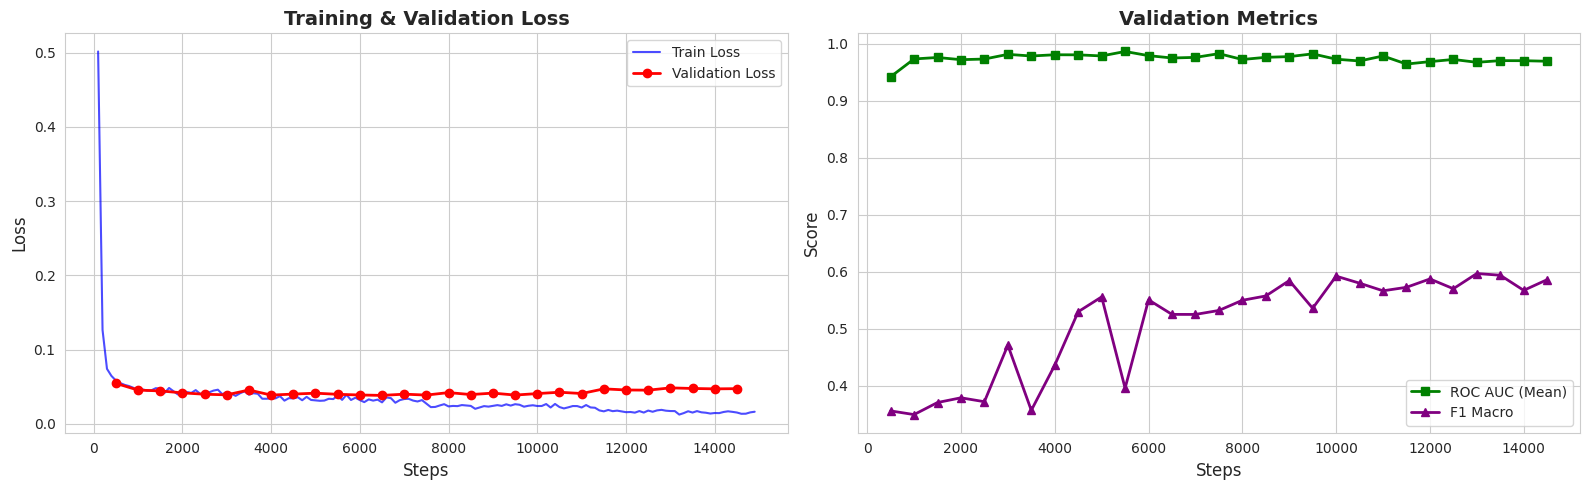


[INFO] Đã vẽ xong biểu đồ và lưu thành file 'training_history.png'


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chạy quá trình huấn luyện
# trainer.train()


def plot_metrics_from_trainer(trainer):
    """
    Hàm trích xuất lịch sử từ HuggingFace Trainer và vẽ biểu đồ.
    """
    history = trainer.state.log_history

    # Khởi tạo các mảng lưu trữ dữ liệu
    train_steps, train_loss = [], []
    eval_steps, eval_loss, eval_auc, eval_f1 = [], [], [], []

    # Duyệt qua lịch sử log
    for log in history:
        if 'loss' in log and 'step' in log:
            # Log của tập Train
            train_steps.append(log['step'])
            train_loss.append(log['loss'])
        elif 'eval_loss' in log and 'step' in log:
            # Log của tập Validation
            eval_steps.append(log['step'])
            eval_loss.append(log['eval_loss'])

            # Lấy metrics (nếu có, không có thì gán 0 để tránh lỗi)
            eval_auc.append(log.get('eval_roc_auc', 0))
            eval_f1.append(log.get('eval_f1_macro', 0))

    # Bắt đầu vẽ (1 hàng, 2 cột)
    sns.set_style("whitegrid")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # --- Biểu đồ 1: Loss ---
    ax1.plot(train_steps, train_loss, label='Train Loss', color='blue', alpha=0.7)
    if eval_steps: # Nếu có đánh giá validation
        ax1.plot(eval_steps, eval_loss, label='Validation Loss', color='red', marker='o', linewidth=2)

    ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Steps', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend()

    # --- Biểu đồ 2: Metrics (ROC-AUC & F1) ---
    if eval_steps:
        ax2.plot(eval_steps, eval_auc, label='ROC AUC (Mean)', color='green', marker='s', linewidth=2)
        ax2.plot(eval_steps, eval_f1, label='F1 Macro', color='purple', marker='^', linewidth=2)

    ax2.set_title('Validation Metrics', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Steps', fontsize=12)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.legend()

    # Hiển thị trên Colab
    plt.tight_layout()
    plt.show()

    # Lưu lại thành file ảnh chất lượng cao để tải về (tùy chọn)
    fig.savefig("training_history.png", dpi=300, bbox_inches='tight')
    print("\n[INFO] Đã vẽ xong biểu đồ và lưu thành file 'training_history.png'")

# Gọi hàm để vẽ
plot_metrics_from_trainer(trainer)

In [16]:
# Lưu dictionary BEST_THRESHOLDS vào file JSON
import json
with open('best_thresholds.json', 'w', encoding='utf-8') as f:
    json.dump(BEST_THRESHOLDS, f, ensure_ascii=False, indent=4)

print("Đã lưu best_thresholds.json thành công!")

Đã lưu best_thresholds.json thành công!


In [17]:
from huggingface_hub import notebook_login

# Cell này sẽ hiện ra một ô để bạn dán Access Token (Write) vào
notebook_login()

In [19]:
REPO_NAME = "tinhuynh79/bert-toxic-comment-classifier"


model.push_to_hub(REPO_NAME)
tokenizer.push_to_hub(REPO_NAME)

print(f"Đã push model thành công lên: https://huggingface.co/{REPO_NAME}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...j98j5rf/model.safetensors:   0%|          | 14.2kB /  438MB            

README.md: 0.00B [00:00, ?B/s]

Đã push model thành công lên: https://huggingface.co/tinhuynh79/bert-toxic-comment-classifier
